In [ ]:
import numpy as np
import pandas as pd
from lib.dataprep import Cleaning, Imputation, RoughFeatureReduction, FeatureSelector, Balancer
from lib.datamodeling import DataModeler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [2]:
X = pd.read_csv("../data/secom.data", sep=" ", header=None, na_values="NaN")
y = pd.read_csv("../data/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

X_train, X_test, y_train, y_test = train_test_split(X, y["label"], test_size=0.2, random_state=42, stratify=y["label"])
print("Original:", X.shape, "| Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Original: (1567, 590) | Train shape: (1253, 590) | Test shape: (314, 590)


In [3]:
y_train = y_train.replace({-1: 0})
y_test = y_test.replace({-1: 0})

In [4]:
# ---------------------------------------------- Training Data Preprocessing ----------------------------------------------
X_train_cleaned, has_invalid_strings = Cleaning().flag_missing_values(X_train)
print(f"Missing values flagged. Total Missing Values: {X_train_cleaned.isnull().sum().sum()}. DataFrame shape: {X_train_cleaned.shape}\n")

X_train_cleaned = Cleaning().cap_outlier_using_3sigma_rule(X_train_cleaned)
print(f"Outliers have been capped using the 3-sigma rule. DataFrame shape: {X_train_cleaned.shape}\n")

missingness_threshold = 0.6
X_train_cleaned = RoughFeatureReduction().remove_features_by_missingness_threshold(X_train_cleaned, missingness_threshold)
print(f"Features with more than {missingness_threshold*100}% missing values have been removed. DataFrame shape: {X_train_cleaned.shape}\n")

X_train_cleaned = RoughFeatureReduction().remove_constant_features(X_train_cleaned)
print(f"Constant features have been removed. DataFrame shape: {X_train_cleaned.shape}\n")

scaler = Imputation().fit_scaler(X_train_cleaned)
X_train_scaled = Imputation().transform_scaler(X_train_cleaned, scaler)
imputer = Imputation().fit_imputer(X_train_scaled)
X_train_imputed = Imputation().transform_imputer(X_train_scaled, imputer)
print(f"Training data has been scaled and imputed. Total Missing Values: {X_train_imputed.isnull().sum().sum()}. DataFrame shape: {X_train_imputed.shape}\n")

Missing values flagged. Total Missing Values: 33868. DataFrame shape: (1253, 590)

Outliers have been capped using the 3-sigma rule. DataFrame shape: (1253, 590)

Features with more than 60.0% missing values have been removed. DataFrame shape: (1253, 566)

Constant features have been removed. DataFrame shape: (1253, 450)

Training data has been scaled and imputed. Total Missing Values: 0. DataFrame shape: (1253, 450)



In [5]:
# Split TRAIN AND EVAL
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_imputed, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train_split, y_train_split.values.ravel())
y_pred = rf_model.predict(X_val_split)
DataModeler().evaluate_model(y_val_split, y_pred)

Accuracy: 0.9322709163346613

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       234
           1       0.00      0.00      0.00        17

    accuracy                           0.93       251
   macro avg       0.47      0.50      0.48       251
weighted avg       0.87      0.93      0.90       251


Confusion Matrix:
 [[234   0]
 [ 17   0]] 



c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classif

In [7]:
X_train_selected, selected_features = FeatureSelector().boruta_select(X_train_imputed, y_train)
print(f"Feature selection completed. DataFrame shape: {X_train_selected.shape}\n")

X_train_balanced, y_train_balanced = Balancer().apply_smote(X_train_selected, y_train)
print(f"Dataset balanced using SMOTE. Balanced DataFrame shape: {X_train_balanced.shape}")

Feature selection completed. DataFrame shape: (1253, 12)

Before SMOTE:
label
0    1170
1      83
Name: count, dtype: int64

After SMOTE:
label
0    1170
1    1170
Name: count, dtype: int64
Dataset balanced using SMOTE. Balanced DataFrame shape: (2340, 12)


In [8]:
# Split TRAIN AND EVAL
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_balanced, 
    y_train_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_balanced
)

Accuracy: 0.9294871794871795

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       234
           1       0.90      0.96      0.93       234

    accuracy                           0.93       468
   macro avg       0.93      0.93      0.93       468
weighted avg       0.93      0.93      0.93       468


Confusion Matrix:
 [[210  24]
 [  9 225]] 


Total cost = 6000


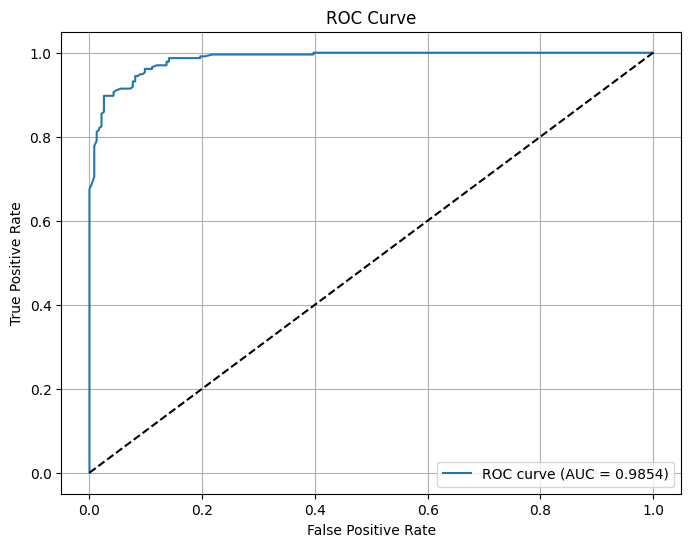

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train_split, y_train_split.values.ravel())
y_pred = rf_model.predict(X_val_split)
cm, total_cost = DataModeler().evaluate_model(y_val_split, y_pred, return_cm_cost=True)
print(f"\nTotal cost = {total_cost}")

# Get predicted probabilities for class 1 and AUC/ROC analysis
y_proba = rf_model.predict_proba(X_val_split)[:, 1]
DataModeler().auc_and_roc_curve(y_val_split, y_proba)

In [10]:
# ---------------------------------------------- Test Data Preprocessing ----------------------------------------------
# Scale using training scaler
X_test = X_test[X_train_cleaned.columns]
X_test_scaled = scaler.transform(X_test)

# Impute using training imputer
X_test_imputed = imputer.transform(X_test_scaled)

# Convert back to DataFrame with original column names
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

# Select Boruta features
# selected_features = [int(f) for f in selected_features]
X_test_selected = X_test_imputed[selected_features]

print(f"Training shape after processing: {X_train_selected.shape}")
print(f"Test shape after processing: {X_test_selected.shape}")

Training shape after processing: (1253, 12)
Test shape after processing: (314, 12)


Accuracy: 0.9044585987261147

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       293
           1       0.26      0.24      0.25        21

    accuracy                           0.90       314
   macro avg       0.60      0.60      0.60       314
weighted avg       0.90      0.90      0.90       314


Confusion Matrix:
 [[279  14]
 [ 16   5]] 

Total cost = 7800


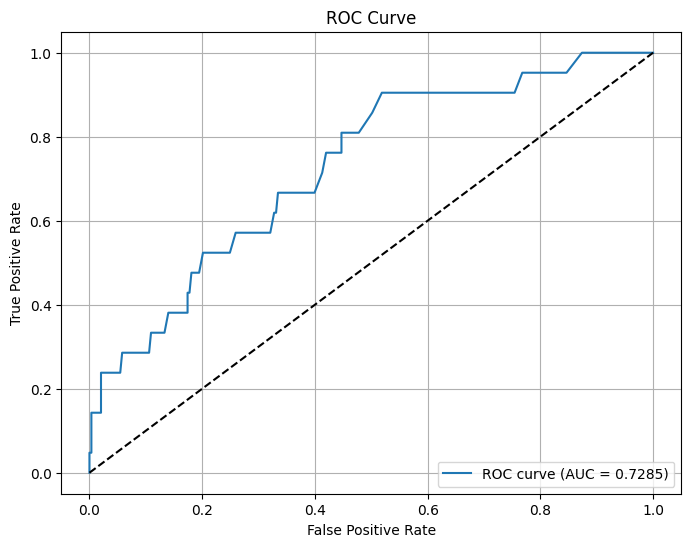

In [11]:
# rf = RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     class_weight="balanced",  # important for imbalance
#     n_jobs=-1
# )

# rf.fit(X_train_balanced, y_train_balanced.values.ravel())
y_pred = rf_model.predict(X_test_selected)

cm, total_cost = DataModeler().evaluate_model(y_test, y_pred, return_cm_cost=True)
print(f"Total cost = {total_cost}")

# Get predicted probabilities for class 1 and AUC/ROC analysis
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]
DataModeler().auc_and_roc_curve(y_test, y_proba)

In [12]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "class_weight": ["balanced", {0:1, 1:3}, {0:1, 1:5}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="recall",          # focus on detecting faulty wavers
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_balanced, y_train_balanced.values.ravel())

print("Best params:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'class_weight': {0: 1, 1: 5}, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 300}
Best CV recall: 0.994017094017094


Accuracy: 0.5573248407643312

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70       293
           1       0.09      0.62      0.16        21

    accuracy                           0.56       314
   macro avg       0.52      0.59      0.43       314
weighted avg       0.90      0.56      0.66       314


Confusion Matrix:
 [[162 131]
 [  8  13]] 



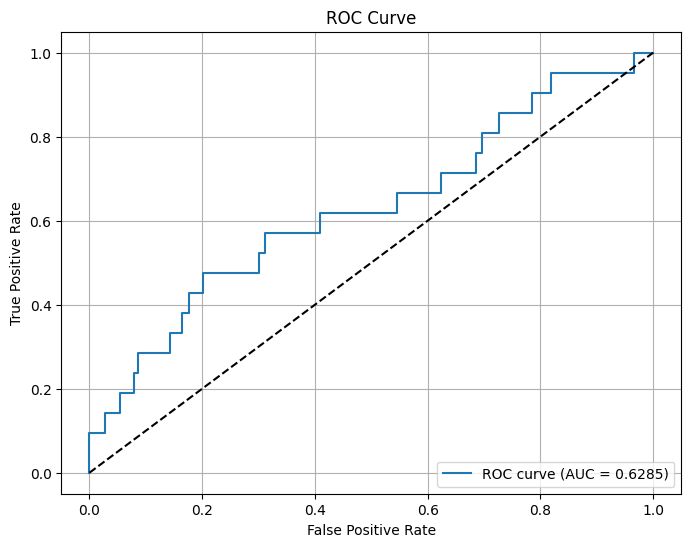

In [13]:
y_pred_best = best_model.predict(X_test_selected)
cm_best, total_cost_best = DataModeler().evaluate_model(y_test, y_pred_best, return_cm_cost=True)

# Get predicted probabilities for class 1 and AUC/ROC analysis
y_proba = best_model.predict_proba(X_test_selected)[:, 1]
DataModeler().auc_and_roc_curve(y_test, y_proba)

In [14]:
y_proba = best_model.predict_proba(X_val_split)[:, 1]  # probability of class 1

def evaluate_threshold(threshold):
    y_pred_thr = (y_proba >= threshold).astype(int)
    _, cost = DataModeler().evaluate_model(y_val_split, y_pred_thr, evaluation_report=False, return_cm_cost=True)
    print(f"Threshold {threshold:.2f} -> total cost {cost}")
    return cost

thresholds = np.linspace(0.05, 0.95, 19)
results = []

for thr in thresholds:
    cost = evaluate_threshold(thr)
    results.append((thr, cost))

for thr, cost in results:
    print(f"Threshold {thr:.2f} -> total cost {cost}")

    
best_thr, best_cost = min(results, key=lambda x: x[1])
print(f"\nBest threshold by cost: {best_thr:.2f} with total cost {best_cost}")


Threshold 0.05 -> total cost 21400
Threshold 0.10 -> total cost 20300
Threshold 0.15 -> total cost 19200
Threshold 0.20 -> total cost 18500
Threshold 0.25 -> total cost 17600
Threshold 0.30 -> total cost 14700
Threshold 0.35 -> total cost 13700
Threshold 0.40 -> total cost 13000
Threshold 0.45 -> total cost 12600
Threshold 0.50 -> total cost 11500
Threshold 0.55 -> total cost 11400
Threshold 0.60 -> total cost 11300
Threshold 0.65 -> total cost 11300
Threshold 0.70 -> total cost 10300
Threshold 0.75 -> total cost 11200
Threshold 0.80 -> total cost 11700
Threshold 0.85 -> total cost 16700
Threshold 0.90 -> total cost 51900
Threshold 0.95 -> total cost 93600
Threshold 0.05 -> total cost 21400
Threshold 0.10 -> total cost 20300
Threshold 0.15 -> total cost 19200
Threshold 0.20 -> total cost 18500
Threshold 0.25 -> total cost 17600
Threshold 0.30 -> total cost 14700
Threshold 0.35 -> total cost 13700
Threshold 0.40 -> total cost 13000
Threshold 0.45 -> total cost 12600
Threshold 0.50 -> to

Accuracy: 0.6815286624203821

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80       293
           1       0.11      0.52      0.18        21

    accuracy                           0.68       314
   macro avg       0.53      0.61      0.49       314
weighted avg       0.90      0.68      0.76       314


Confusion Matrix:
 [[203  90]
 [ 10  11]] 



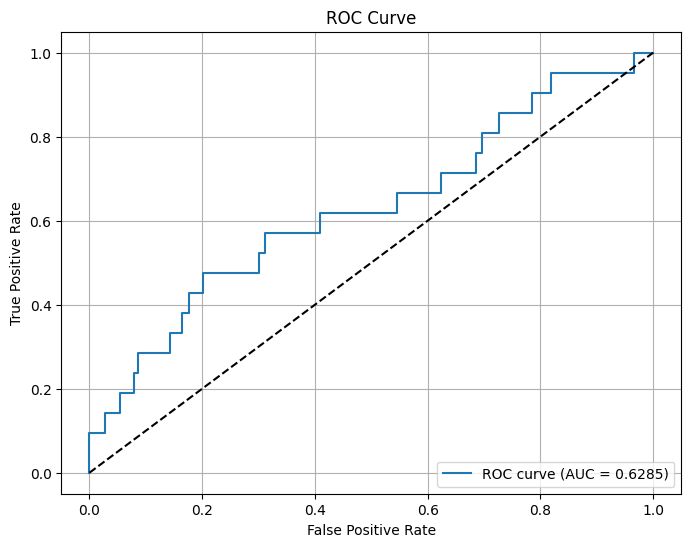

In [ ]:
y_test_proba = best_model.predict_proba(X_test_selected)[:, 1]
y_test_pred = (y_test_proba >= best_thr).astype(int)

cm, total_cost = DataModeler().evaluate_model(y_test, y_test_pred, return_cm_cost=True)

In [17]:
# # Save the cleaned and balanced training data to CSV files
# X_train_balanced.to_csv("../data/X_train_balanced.csv", index=False)
# y_train_balanced.to_csv("../data/y_train_balanced.csv", index=False)
# X_test_selected.to_csv("../data/X_test_cleaned.csv", index=False)
# y_test.to_csv("../data/y_test.csv", index=False)

# # Save the selected features for later use
# pd.Series(selected_features, name="feature").to_csv("../data/selected_features.csv", index=False)